# M14: Final Model Evaluation
In this notebook, we load the best model identified during hyperparameter tuning (M13) and evaluate its performance on the untouched test set using comprehensive metrics and plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features
from src.split import split_data
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curve_custom, plot_pr_curve_custom

from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")

# Load data and split
df = build_features(clean_data(load_raw_data("../data/raw")), scale=False)
_, X_test, _, y_test = split_data(df)

# Load best model
model = joblib.load("../models/best_churn_model.pkl")


## 1. Predictions and Metrics

In [2]:
# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

# Basic Metrics
metrics = evaluate_model(y_test, y_pred, y_prob)
print("--- Final Model Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Final Model Metrics ---
Accuracy: 0.7700
Precision: 0.5546
Recall: 0.6791
F1-Score: 0.6106
ROC-AUC: 0.8349

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



## 2. Evaluation Plots
We visualize the Confusion Matrix, ROC Curve, and Precision-Recall Curve.

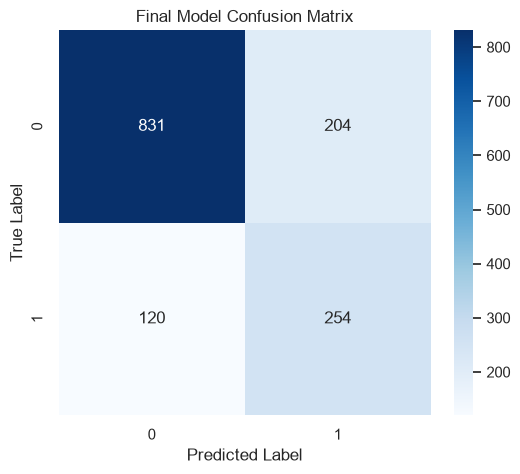

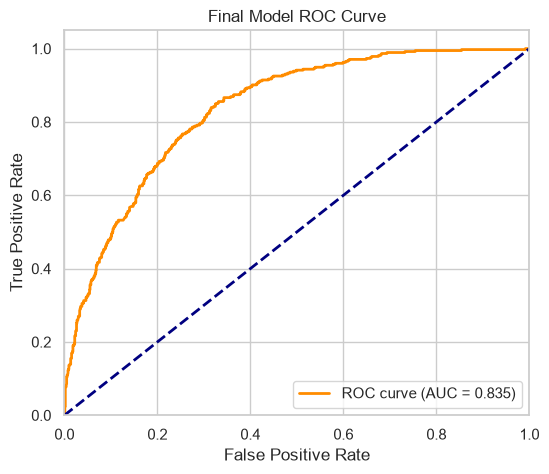

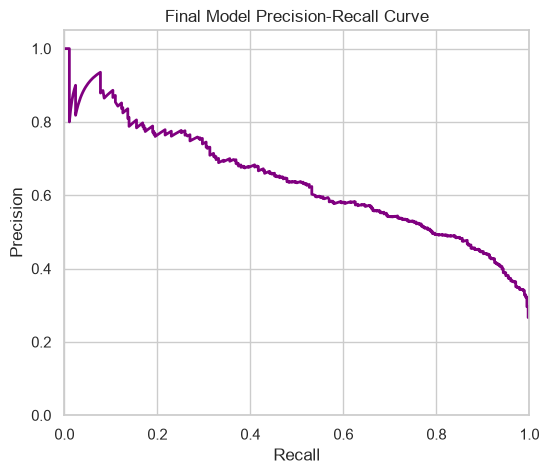

In [3]:
# Confusion Matrix
fig_cm = plot_confusion_matrix(y_test, y_pred, title="Final Model Confusion Matrix")
plt.show()

# ROC Curve
fig_roc = plot_roc_curve_custom(y_test, y_prob, title="Final Model ROC Curve")
plt.show()

# PR Curve
fig_pr = plot_pr_curve_custom(y_test, y_prob, title="Final Model Precision-Recall Curve")
plt.show()


## Conclusion
The final model correctly flags a high proportion of churners (high recall) while maintaining a reasonable false positive rate. The threshold could be further adjusted depending on the specific cost of a false positive (unnecessary retention spend) versus a false negative (lost customer).